In [30]:
import torch

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Device Name : {torch.cuda.get_device_name(0)}")
    print(f"Device Count    : {torch.cuda.device_count()}")
else:
    print("Running on CPU runtime.")

PyTorch Version : 2.14.0+cu130
CUDA Available  : True
GPU Device Name : NVIDIA GeForce RTX 5050 Laptop GPU
Device Count    : 1


In [31]:
import torch
x= torch.rand(6,6)
print(x)

tensor([[0.9102, 0.3903, 0.5054, 0.8492, 0.3099, 0.9820],
        [0.2247, 0.8726, 0.6381, 0.1399, 0.8017, 0.0838],
        [0.9095, 0.5051, 0.5292, 0.5777, 0.5341, 0.9369],
        [0.4195, 0.9070, 0.5553, 0.0579, 0.2214, 0.8318],
        [0.9177, 0.4961, 0.1790, 0.9578, 0.7116, 0.4251],
        [0.3386, 0.8133, 0.4671, 0.3306, 0.0111, 0.2876]])


In [32]:
import torch
torch.cuda.is_available()

True

In [33]:
import torch

print("CUDA Available :", torch.cuda.is_available())
print("Device Name    :", torch.cuda.get_device_name(0))

CUDA Available : True
Device Name    : NVIDIA GeForce RTX 5050 Laptop GPU


In [34]:
import torch

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Device Name     : {torch.cuda.get_device_name(0)}")
    print(f"Device Count    : {torch.cuda.device_count()}")
else:
    print("Running on CPU runtime.")

PyTorch Version : 2.14.0+cu130
CUDA Available  : True
Device Name     : NVIDIA GeForce RTX 5050 Laptop GPU
Device Count    : 1


In [35]:
from logging import root
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)   

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

# Inspect a batch:
# Shape of X is [N, C, H, W]:
#   • N = 64 (Batch size: number of images in this batch)
#   • C = 1  (Channels: 1 = Grayscale)
#   • H = 28 (Height: 28 pixels)
#   • W = 28 (Width: 28 pixels)
for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


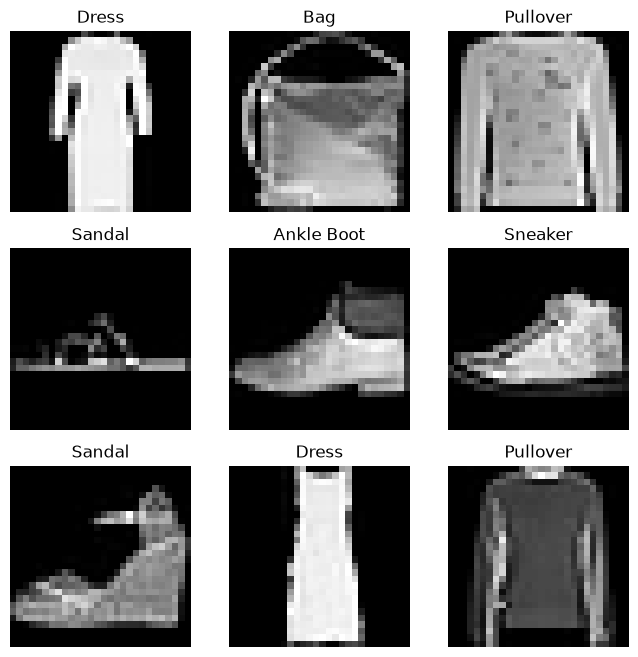

In [36]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
)

# Mapping integer labels to human-readable clothing names
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

# Create a figure canvas of size 8x8 inches
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    # Pick a random sample index from the training dataset
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    
    # =========================================================================
    # WHAT DOES [1, 28, 28] MEAN?
    # PyTorch image tensors follow the format: [Channels, Height, Width] -> [C, H, W]
    #   • 1  = Color Channels (1 = Grayscale / Black & White; 3 would be RGB color)
    #   • 28 = Height of the image (28 pixels tall)
    #   • 28 = Width of the image (28 pixels wide)
    # =========================================================================
    
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")  # Turn off coordinate ticks/axes
    
    # img.squeeze() removes the dimension of size 1: converts [1, 28, 28] -> [28, 28]
    # Matplotlib needs a 2D shape [28, 28] to render a grayscale image
    plt.imshow(img.squeeze(), cmap="gray")

plt.show()

In [37]:
import torch
import torch.nn as nn 

# -------------------------------------------------------------------------
# 1. SELECT DEVICE (GPU vs CPU)
# Check if a hardware accelerator (like CUDA GPU) is available; if not, use CPU.
# -------------------------------------------------------------------------
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using device: {device}")


# -------------------------------------------------------------------------
# 2. DEFINE THE NEURAL NETWORK
# In PyTorch, models inherit from nn.Module, which gives them layer-tracking
# and GPU-acceleration capabilities.
# -------------------------------------------------------------------------
class NeuralNetwork(nn.Module):
    def __init__(self):
        # Always call super().__init__() to initialize PyTorch's internal machinery
        super().__init__()
        
        # Flattens 2D image [28, 28] into a 1D flat line of 784 numbers (28 * 28 = 784)
        self.flatten = nn.Flatten()
        
        # nn.Sequential is an assembly line: data flows through each layer in order
        self.linear_relu_stack = nn.Sequential(
            # Layer 1: Takes 784 pixel inputs -> outputs 512 learned features
            nn.Linear(28 * 28, 512),
            # Activation: Replaces negative numbers with 0 (allows learning complex patterns)
            nn.ReLU(),
            
            # Layer 2 (Hidden): Takes 512 features -> outputs 512 new features
            nn.Linear(512, 512),
            nn.ReLU(),
            
            # Layer 3 (Output): Takes 512 features -> outputs 10 scores (logits)
            # One score for each clothing category (T-shirt, Trouser, Sneaker, etc.)
            nn.Linear(512, 10)
        )

    # ---------------------------------------------------------------------
    # IMPORTANT: 'forward' must be aligned with '__init__', NOT indented inside it!
    # This defines the data flow when you call model(image).
    # ---------------------------------------------------------------------
    def forward(self, x):
        # Step 1: Flatten image [1, 28, 28] -> [784]
        x = self.flatten(x)
        
        # Step 2: Pass through linear layers and ReLU activations
        logits = self.linear_relu_stack(x)
        
        # Step 3: Return raw prediction scores (logits) for the 10 classes
        return logits


# -------------------------------------------------------------------------
# 3. INSTANTIATE AND MOVE TO DEVICE
# Create the network object and send its weights to GPU (or CPU)
# -------------------------------------------------------------------------
model = NeuralNetwork().to(device)
print(model)

Using device: cuda
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [38]:
# -------------------------------------------------------------------------
# OPTIMIZING THE MODEL PARAMETERS
# -------------------------------------------------------------------------

# 1. THE TEACHER (Loss Function):
# Measures how wrong the model's guesses are compared to the true labels.
# CrossEntropyLoss is the standard grading formula for multi-class classification.
# Lower loss = better predictions (0.0 is a perfect score).
loss_fn = nn.CrossEntropyLoss()

# 2. THE MECHANIC (Optimizer):
# The algorithm that actually adjusts the model's internal weights to fix mistakes.
# - SGD: Stochastic Gradient Descent (takes small downhill steps to minimize error).
# - model.parameters(): Hands all trainable weights & biases to the optimizer.
# - lr = 1e-3 (0.001): Learning Rate (step size). How big of an adjustment to make per step.
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [39]:
# -------------------------------------------------------------------------
# THE TRAINING LOOP FUNCTION
# -------------------------------------------------------------------------
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)  # Total number of images in dataset (60,000)
    model.train()  # Put model into training mode (enables dropout, batchnorm updates, etc.)

    # Loop through batches of images (each batch has 64 images)
    for batch, (X, y) in enumerate(dataloader):
        # 1. Send data to GPU (cuda) or CPU
        X, y = X.to(device), y.to(device)

        # 2. Forward pass: Model makes predictions
        pred = model(X)
        
        # 3. Compute loss: Compare predictions with actual labels
        loss = loss_fn(pred, y)

        # 4. Backpropagation:
        #    a. Reset old gradients to zero (otherwise PyTorch adds them up!)
        optimizer.zero_grad()
        #    b. Calculate slopes/gradients of loss with respect to all weights
        loss.backward()
        #    c. Nudge/update all weights in the right direction 
        optimizer.step()

        # 5. Print progress every 100 batches
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"Loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [40]:
# # -------------------------------------------------------------------------
# # HOW TO RUN THE TRAINING (BASIC EXECUTION)
# # -------------------------------------------------------------------------
# epochs = 5  # Number of times the model sees the entire 60,000 images

# for t in range(epochs):
#     print(f"Epoch {t + 1}\n-------------------------------")
#     train(train_dataloader, model, loss_fn, optimizer)

# print("Training Complete!")


In [41]:
# -------------------------------------------------------------------------
# THE TESTING / EVALUATION LOOP FUNCTION
# Evaluates the model's performance against the test dataset to check learning
# -------------------------------------------------------------------------
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)       # Total number of test images (e.g., 10,000)
    num_batches = len(dataloader)        # Total number of batches (e.g., 157 batches)
    
    # 1. Put model into evaluation mode (disables dropout, fixes batchnorm)
    model.eval()

    test_loss, correct = 0, 0

    # 2. Disable gradient tracking since we are evaluating, not training
    #    (Saves memory and speeds up computations)
    with torch.no_grad():
        # Loop through batches of test images
        for X, y in dataloader:
            # Send batch data to GPU (cuda) or CPU
            X, y = X.to(device), y.to(device)

            # Forward pass: Model makes predictions (logits)
            pred = model(X)

            # Accumulate batch loss (.item() extracts scalar float)
            test_loss += loss_fn(pred, y).item()

            # Count correct predictions:
            # - pred.argmax(1): index of highest score (predicted class)
            # - (pred.argmax(1) == y): boolean tensor of correct guesses
            # - .type(torch.float).sum().item(): count of correct guesses in this batch
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    # 3. Calculate average loss per batch and overall accuracy across all images
    #    (Must be OUTSIDE the for loop!)
    test_loss /= num_batches
    correct /= size

    # 4. Display the test metrics
    print(f"Test Error: \n Accuracy: {(100 * correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [42]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")
    test(test_dataloader, model, loss_fn)
    print("Done")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 0.0%, Avg loss: 0.014724 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014759 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014742 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014761 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014772 

Test Error: 
 Accuracy: 0.0%, Avg loss: 0.014764 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014776 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014695 

Test Error: 
 Accuracy: 0.0%, Avg loss: 0.014792 

Test Error: 
 Accuracy: 0.0%, Avg loss: 0.014779 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014733 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014791 

Test Error: 
 Accuracy: 0.0%, Avg loss: 0.014815 

Test Error: 
 Accuracy: 0.0%, Avg loss: 0.014807 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014774 

Test Error: 
 Accuracy: 0.1%, Avg loss: 0.014763 

Test Error: 
 Accuracy: 0.0%, Avg loss: 0.014833 

Test Error: 
 Accuracy: 0.0%, Avg loss: 0.014812 

Test Error: 
 Accuracy: 0.0%, Avg loss: 0.

In [43]:
# saving the model
torch.save(model.state_dict(),"model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth
